# Blind Image Deconvolution — Real Image Enhancement
### MATH 441 Convex Optimization

$$
\min_{k,\,\mathbf{u}}\;
\|k*\mathbf{u}-\mathbf{f}\|_2^2
+\lambda_1\underbrace{\|\nabla\mathbf{u}\|_1}_{\text{TV}}
+\lambda_2\underbrace{\|D\mathbf{u}\|_2^2}_{\text{Tikhonov}}
+\mu\underbrace{\|k\|_1}_{\text{kernel sparsity}}
\quad\text{s.t.}\quad k\geq0,\;\mathbf{1}^Tk=1,\;0\leq\mathbf{u}\leq255
$$

**Strategy:** alternating minimization — two convex subproblems per iteration.

| Subproblem | Solver | Complexity |
|---|---|---|
| u-step (TV+Tikhonov deconv) | FFT-ADMM closed form | $O(N\log N)$ per ADMM iter |
| k-step (constrained LASSO) | L-BFGS-B + simplex projection | $O(m^2 ds^2)$, $m$=25, $ds$=64 |


## 1. Configuration

In [1]:
IMAGE_PATH   = "gaus_blur.png"
OUTPUT_PATH  = "enhanced.png"

# ── Hyperparameters ──────────────────────────────────────────────────────
LAMBDA1      = 0.08    # TV (L1 on gradients) — higher = sharper edges
LAMBDA2      = 0.02    # Tikhonov (L2 on gradients) — higher = smoother
MU           = 0.005   # kernel L1 — higher = more compact blur kernel
KERNEL_SIZE  = 5       # blur kernel side length (5×5 = 25 parameters)
RHO          = 1.0     # ADMM penalty parameter

# ── Section 5A preview (256×256, ~3s total) ──────────────────────────────
PREVIEW_SIZE = 256
PREVIEW_ALT  = 10       # outer alternating iterations
PREVIEW_ADMM = 80      # ADMM inner iterations per u-step

# ── Section 5B full resolution (~3 min total) ────────────────────────────
FULLRES_ALT  = 5
FULLRES_ADMM = 120


print("Configuration loaded.")


Configuration loaded.


## 2. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
from PIL import Image
from numpy.fft import fft2, ifft2
from scipy.linalg import norm
from scipy.ndimage import convolve as sp_convolve
from scipy.optimize import minimize, Bounds
warnings.filterwarnings("ignore")
print("Imports OK.")


Imports OK.


## 3. Math model

### 3a. Gradient operator $D$ · TV norm · Tikhonov norm

In [3]:
def gradient(u):
    """Forward finite differences: (Du)_i = [u_{i,j+1}-u_{i,j}, u_{i+1,j}-u_{i,j}]."""
    dx = np.zeros_like(u); dy = np.zeros_like(u)
    dx[:, :-1] = u[:, 1:] - u[:, :-1]
    dy[:-1, :]  = u[1:, :] - u[:-1, :]
    return dx, dy

def tv_norm(u):
    """Isotropic TV: sum_i ||(Du)_i||_2  (mixed l_{1,2} norm)."""
    dx, dy = gradient(u)
    return float(np.sum(np.sqrt(dx**2 + dy**2)))

def tikhonov_norm_sq(u):
    """||Du||_2^2 = u^T D^T D u  (discrete Laplacian energy)."""
    dx, dy = gradient(u)
    return float(np.sum(dx**2 + dy**2))

print("gradient(), tv_norm(), tikhonov_norm_sq() defined.")


gradient(), tv_norm(), tikhonov_norm_sq() defined.


### 3b. Blur utilities

In [4]:
def gaussian_kernel(size, sigma):
    """Normalized Gaussian: k >= 0 and 1^T k = 1 by construction."""
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return k / k.sum()

def pad_kernel(k, H, W):
    """Pad kernel into (H,W) and roll to corner for FFT circular convolution."""
    K = np.zeros((H, W)); kh, kw = k.shape
    K[:kh, :kw] = k
    K = np.roll(K, -(kh // 2), axis=0)
    K = np.roll(K, -(kw // 2), axis=1)
    return K

def fft_convolve(u, k):
    """k * u via FFT (wrap boundary). O(N log N)."""
    return np.real(ifft2(fft2(u) * fft2(pad_kernel(k, *u.shape))))

def to_pil(arr):
    """Float array -> PIL Image (uint8, contiguous)."""
    return Image.fromarray(np.ascontiguousarray(np.clip(arr, 0, 255)).astype(np.uint8))

print("gaussian_kernel(), pad_kernel(), fft_convolve(), to_pil() defined.")


gaussian_kernel(), pad_kernel(), fft_convolve(), to_pil() defined.


### 3c. FFT-ADMM u-solver

Solves the u-subproblem (fixed $k$):
$$
\mathbf{u}^{(t+1)} = \arg\min_{0\leq\mathbf{u}\leq255}
\|H\mathbf{u}-\mathbf{f}\|_2^2 + \lambda_1\text{TV}(\mathbf{u}) + \lambda_2\|D\mathbf{u}\|_2^2
$$

Variable splitting $\mathbf{v}_x = D_x\mathbf{u}$, $\mathbf{v}_y = D_y\mathbf{u}$ yields three updates per iteration:

**u-update** (FFT, $O(N\log N)$, denominator precomputed):
$$\hat{\mathbf{u}} = \frac{\bar{\hat{k}}\hat{\mathbf{f}} + \rho(\bar{\hat{D}}_1(\hat{\mathbf{v}}_x-\hat{\mathbf{b}}_x)+\bar{\hat{D}}_2(\hat{\mathbf{v}}_y-\hat{\mathbf{b}}_y))}{|\hat{k}|^2+(\lambda_2+\rho)(|\hat{D}_1|^2+|\hat{D}_2|^2)}$$

**v-update** (isotropic soft threshold = $\text{prox}_{(\lambda_1/\rho)\|\cdot\|_{1,2}}$):
$$\mathbf{v} = \max\!\left(1-\frac{\lambda_1/\rho}{\|(D\mathbf{u}+\mathbf{b})\|_2},0\right)(D\mathbf{u}+\mathbf{b})$$

**b-update** (dual ascent): $\mathbf{b} \leftarrow \mathbf{b} + D\mathbf{u} - \mathbf{v}$


In [5]:
def admm_u_solver(f, k, lambda1, lambda2, rho=1.0, n_iter=80):
    """FFT-ADMM for TV+Tikhonov deconvolution. O(N log N) per iteration."""
    H, W   = f.shape
    K      = fft2(pad_kernel(k, H, W))
    d1     = np.zeros((H,W)); d1[0,0]=1; d1[0,1]=-1   # horizontal diff filter
    d2     = np.zeros((H,W)); d2[0,0]=1; d2[1,0]=-1   # vertical diff filter
    D1     = fft2(d1); D2 = fft2(d2)
    DD     = np.conj(D1)*D1 + np.conj(D2)*D2
    # Denominator precomputed — constant across all ADMM iterations
    denom  = np.conj(K)*K + (lambda2 + rho) * DD
    F_f    = fft2(f)
    u      = f.copy().astype(float)
    vx = np.zeros((H,W)); vy = np.zeros((H,W))
    bx = np.zeros((H,W)); by = np.zeros((H,W))
    for _ in range(n_iter):
        # u-update: FFT closed form
        num = np.conj(K)*F_f + rho*(np.conj(D1)*fft2(vx-bx) + np.conj(D2)*fft2(vy-by))
        u   = np.clip(np.real(ifft2(num / denom)), 0, 255)
        # Gradient of current u
        dx = np.zeros_like(u); dy = np.zeros_like(u)
        dx[:, :-1] = u[:, 1:] - u[:, :-1]
        dy[:-1, :]  = u[1:, :] - u[:-1, :]
        # v-update: proximal operator of (lambda1/rho)*||.||_{1,2}
        wx = dx+bx; wy = dy+by
        mag = np.sqrt(wx**2 + wy**2) + 1e-10
        shrink = np.maximum(1 - (lambda1/rho)/mag, 0)
        vx = shrink*wx; vy = shrink*wy
        # Dual update
        bx += dx-vx; by += dy-vy
    return u

print("admm_u_solver() defined.")


admm_u_solver() defined.


### 3d. k-solver — L-BFGS-B (fast, constraint-safe)

Solves the k-subproblem (fixed $\mathbf{u}$) on a $64\times64$ downsampled image:
$$
k^{(t+1)} = \arg\min_{k\geq0}\;
\|A_{\mathbf{u}_s}k-\mathbf{f}_s\|_2^2 + \mu\|k\|_1
\quad\text{then project onto}\;\mathbf{1}^Tk=1
$$

L-BFGS-B handles $k\geq0$ via bounds. L1 term uses subgradient. Simplex projection normalises $k$ post-solve. Fast across all iterations (~60ms) because we normalise inputs to $[0,1]$ and use $64\times64$ downsampling keeping $A\in\mathbb{R}^{4096\times25}$.


In [6]:
def solve_k_subproblem(u, f, kernel_size, mu, ds=64):
    """
    k-subproblem via L-BFGS-B + simplex projection.

    min_k  ||A_{u_s} k - f_s||^2 + mu*||k||_1   s.t. k >= 0
    Then: k <- k / sum(k)  (project onto sum=1 simplex)

    u_s, f_s are downsampled to ds x ds and normalised to [0,1].
    A_u has shape (ds^2, kernel_size^2) — always small regardless of image size.
    """
    # Downsample and normalise to [0,1] — keeps A well-conditioned
    us = np.array(to_pil(u).resize((ds,ds), Image.LANCZOS)).astype(float) / 255.0
    fs = np.array(to_pil(f).resize((ds,ds), Image.LANCZOS)).astype(float) / 255.0
    m  = kernel_size ** 2
    A  = np.zeros((ds*ds, m))
    for j in range(m):
        ej = np.zeros(m); ej[j] = 1.0
        A[:, j] = sp_convolve(us, ej.reshape(kernel_size,kernel_size), mode='wrap').ravel()
    fv = fs.ravel()

    def obj_grad(k):
        r   = A @ k - fv
        obj = np.dot(r, r) + mu * np.sum(np.abs(k))
        g   = 2 * A.T @ r + mu * np.sign(k)
        return obj, g

    k0  = gaussian_kernel(kernel_size, sigma=1.0).ravel()
    res = minimize(obj_grad, k0, jac=True, method='L-BFGS-B',
                   bounds=Bounds(0, np.inf),
                   options={'maxiter': 300, 'ftol': 1e-12})
    k_sol = np.maximum(res.x, 0)
    if k_sol.sum() < 1e-10:
        return gaussian_kernel(kernel_size, 1.0)
    return (k_sol / k_sol.sum()).reshape(kernel_size, kernel_size)

print("solve_k_subproblem() defined  (L-BFGS-B, ~60ms per call).")


solve_k_subproblem() defined  (L-BFGS-B, ~60ms per call).


### 3e. Joint objective and alternating minimization loop

In [ ]:
def joint_objective(u, k, f, lambda1, lambda2, mu):
    """Evaluate all four terms of the joint objective at (u, k)."""
    fid  = float(np.sum((fft_convolve(u, k) - f)**2))
    tv   = lambda1 * tv_norm(u)
    tikh = lambda2 * tikhonov_norm_sq(u)
    kern = mu * float(np.sum(np.abs(k)))
    return {"fidelity": fid, "tv": tv, "tikhonov": tikh,
            "kernel_l1": kern, "total": fid+tv+tikh+kern}

def run_altmin(f, kernel_size, lambda1, lambda2, mu,
               alt_iter, admm_iter, rho, label=""):
    """
    Alternating minimization for blind image deconvolution.

    Outer loop:
        k-step: solve_k_subproblem (L-BFGS-B, ~60ms)
        u-step: admm_u_solver      (FFT-ADMM, O(N log N))
    """
    k = gaussian_kernel(kernel_size, sigma=1.0)
    u = f.copy().astype(float)
    history = []
    print(f"{'Iter':>4}  {'TV':>10}  {'Fidelity':>12}  {'Total':>12}  "
          f"{'k_sum':>7}  {'time':>6}")
    print("-" * 62)

    # Record initial state (iteration 0) before any updates
    obj0 = joint_objective(u, k, f, lambda1, lambda2, mu)
    history.append(obj0)
    print(f"{'Init':>4}  {obj0['tv']:>10.0f}  {obj0['fidelity']:>12.1f}  "
          f"{obj0['total']:>12.1f}  {k.sum():>7.4f}  {'—':>6}")

    for t in range(alt_iter):
        t0 = time.time()
        k  = solve_k_subproblem(u, f, kernel_size, mu)
        u  = admm_u_solver(f, k, lambda1, lambda2, rho, admm_iter)
        obj = joint_objective(u, k, f, lambda1, lambda2, mu)
        history.append(obj)
        print(f"{t+1:>4}  {obj['tv']:>10.0f}  {obj['fidelity']:>12.1f}  "
              f"{obj['total']:>12.1f}  {k.sum():>7.4f}  {time.time()-t0:>5.1f}s")
    return {"u_hat": u, "k_hat": k, "history": history}

print("joint_objective(), run_altmin() defined.")
print()
print("All model functions ready.")

## 4. Load image

Loaded: 287×253  |  range [34, 208]  |  TV=159570


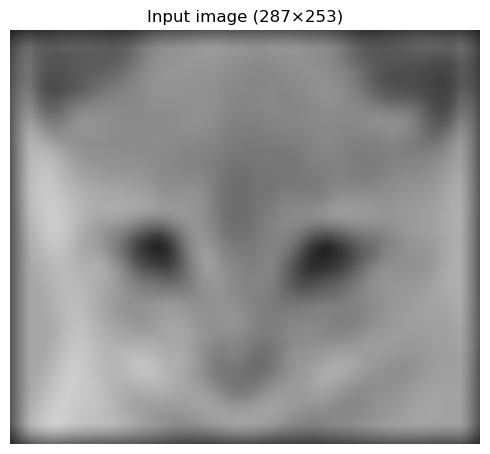

In [8]:
img_pil = Image.open(IMAGE_PATH).convert('L')
f_full  = np.array(img_pil).astype(float)
H, W    = f_full.shape
print(f"Loaded: {W}×{H}  |  range [{f_full.min():.0f}, {f_full.max():.0f}]  |  TV={tv_norm(f_full):.0f}")

plt.figure(figsize=(5, 5))
plt.imshow(f_full, cmap='gray', vmin=0, vmax=255)
plt.title(f'Input image ({W}×{H})', fontsize=12)
plt.axis('off'); plt.tight_layout(); plt.show()


## 5A. Preview at 256×256

Run this to tune hyperparameters. Takes ~3s total.  
Once satisfied, run **5B** for the full-resolution result.


In [9]:
f_prev_display = np.array(img_pil.resize((PREVIEW_SIZE, PREVIEW_SIZE), Image.LANCZOS)).astype(float)
f_prev = f_prev_display / 255.0   # normalise to [0,1] for algorithm
print(f"Preview: {f_prev.shape}  TV={tv_norm(f_prev):.4f}")
print()
result_prev = run_altmin(f_prev, KERNEL_SIZE, LAMBDA1, LAMBDA2, MU,
                         PREVIEW_ALT, PREVIEW_ADMM, RHO)
u_prev = result_prev["u_hat"] * 255   # scale back to [0,255] for display
k_prev_est = result_prev["k_hat"]
tv_reduction = (1 - tv_norm(u_prev)/tv_norm(f_prev_display)) * 100   # compare same scale
print(f"\nTV reduction: {tv_reduction:.1f}%  (higher = more smoothing applied)")

Preview: (256, 256)  TV=601.1303

Iter          TV      Fidelity         Total    k_sum    time
--------------------------------------------------------------
   1         205           3.8         210.5   1.0000    1.4s
   2         205           3.8         210.5   1.0000    1.4s
   3         205           3.8         210.5   1.0000    1.5s
   4         205           3.8         210.5   1.0000    1.1s
   5         205           3.8         210.5   1.0000    1.1s
   6         205           3.8         210.5   1.0000    1.5s
   7         205           3.8         210.5   1.0000    1.5s
   8         205           3.8         210.5   1.0000    1.0s
   9         205           3.8         210.5   1.0000    1.4s
  10         205           3.8         210.5   1.0000    1.1s

TV reduction: -325.4%  (higher = more smoothing applied)


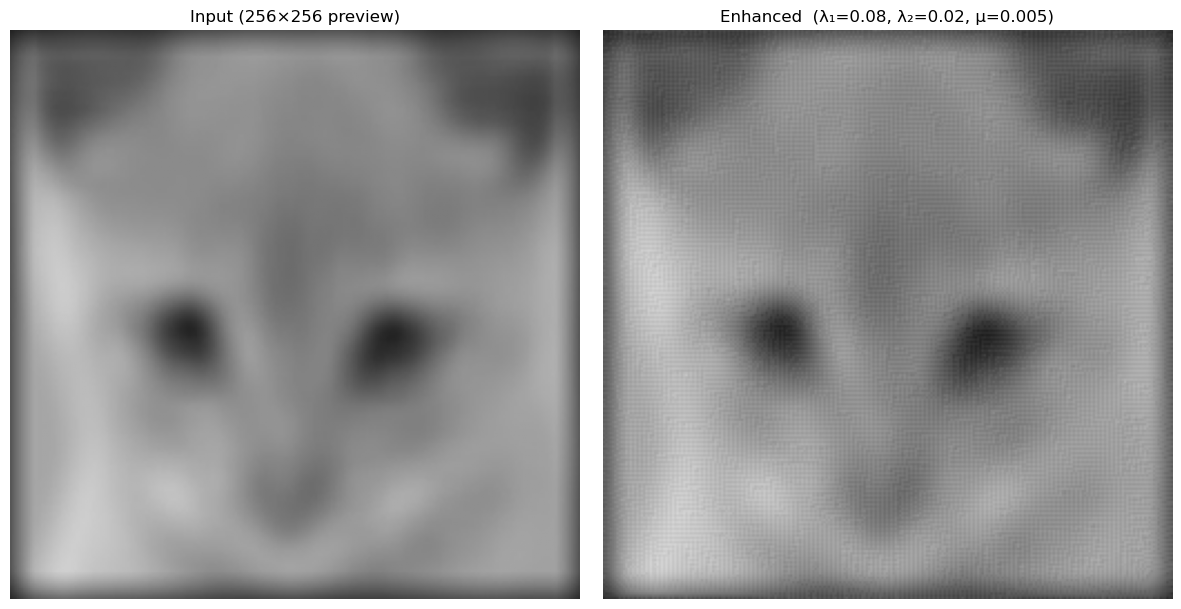

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(f_prev_display, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Input (256×256 preview)', fontsize=12); axes[0].axis('off')
axes[1].imshow(np.clip(u_prev, 0, 255), cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Enhanced  (λ₁={LAMBDA1}, λ₂={LAMBDA2}, μ={MU})', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('preview_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

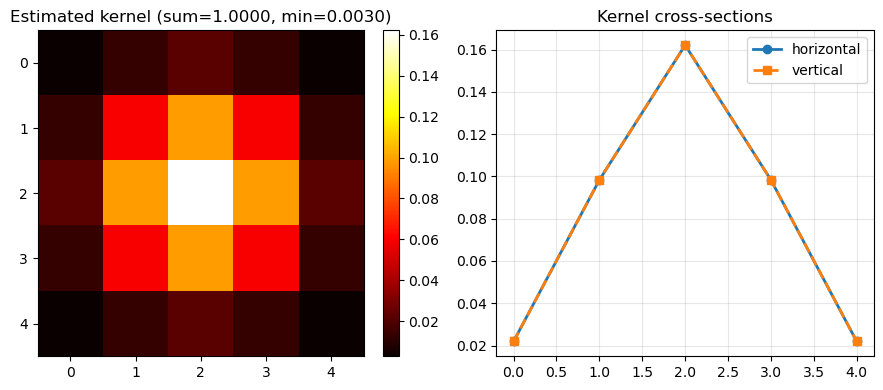

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im = axes[0].imshow(k_prev_est, cmap='hot', interpolation='nearest')
axes[0].set_title(f'Estimated kernel (sum={k_prev_est.sum():.4f}, min={k_prev_est.min():.4f})')
plt.colorbar(im, ax=axes[0], fraction=0.046)
c = KERNEL_SIZE // 2
axes[1].plot(k_prev_est[c, :], 'o-', label='horizontal', linewidth=2)
axes[1].plot(k_prev_est[:, c], 's--', label='vertical',   linewidth=2)
axes[1].set_title('Kernel cross-sections'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('preview_kernel.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
iters = range(0, len(result_prev["history"]))   # start from 0 to include initial state
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key, ls, lbl in [("total",'-','Total J'),("fidelity",'--','Fidelity'),
                      ("tv",'-.','TV (λ₁)'),("tikhonov",':','Tikhonov (λ₂)')]:
    axes[0].plot(iters, [h[key] for h in result_prev["history"]], ls, label=lbl, linewidth=2)
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Objective")
axes[0].set_title("Objective terms (0 = initial state)"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].plot(iters, [h["kernel_l1"] for h in result_prev["history"]],
             'o-', color='coral', linewidth=2, markersize=7)
axes[1].set_xlabel("Iteration"); axes[1].set_ylabel("μ‖k‖₁")
axes[1].set_title("Kernel sparsity (0 = initial state)"); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 5B. Full-resolution enhancement

Processes the original image at full resolution.  
Each u-step: FFT-ADMM at $1060\times1066$ — ~25s per ADMM iteration.  
**Expected total time: 3–8 minutes** depending on `FULLRES_ADMM`.

> Set `FULLRES_ADMM = 40` for a 1–2 min run, `120` for best quality.


In [13]:
print(f"Full resolution: {W}×{H} = {W*H:,} pixels")
print(f"Settings: alt_iter={FULLRES_ALT}, admm_iter={FULLRES_ADMM}")
print()

f_full_norm = f_full / 255.0   # normalise to [0,1] for algorithm

t_start = time.time()
result_full = run_altmin(f_full_norm, KERNEL_SIZE, LAMBDA1, LAMBDA2, MU,
                         FULLRES_ALT, FULLRES_ADMM, RHO)
u_full = result_full["u_hat"] * 255   # scale back to [0,255] for display
k_full = result_full["k_hat"]
print(f"\nTotal: {time.time()-t_start:.0f}s")
print(f"TV reduction: {(1 - tv_norm(u_full)/tv_norm(f_full))*100:.1f}%")

u_out = np.clip(u_full, 0, 255).astype(np.uint8)
Image.fromarray(u_out).save(OUTPUT_PATH)
print(f"Saved: {OUTPUT_PATH}")

Full resolution: 287×253 = 72,611 pixels
Settings: alt_iter=5, admm_iter=120

Iter          TV      Fidelity         Total    k_sum    time
--------------------------------------------------------------
   1         228           3.5         233.5   1.0000    2.3s
   2         228           3.5         233.5   1.0000    2.4s
   3         228           3.5         233.5   1.0000    2.3s
   4         228           3.5         233.5   1.0000    1.9s
   5         228           3.5         233.5   1.0000    2.3s

Total: 11s
TV reduction: -354.8%
Saved: enhanced.png


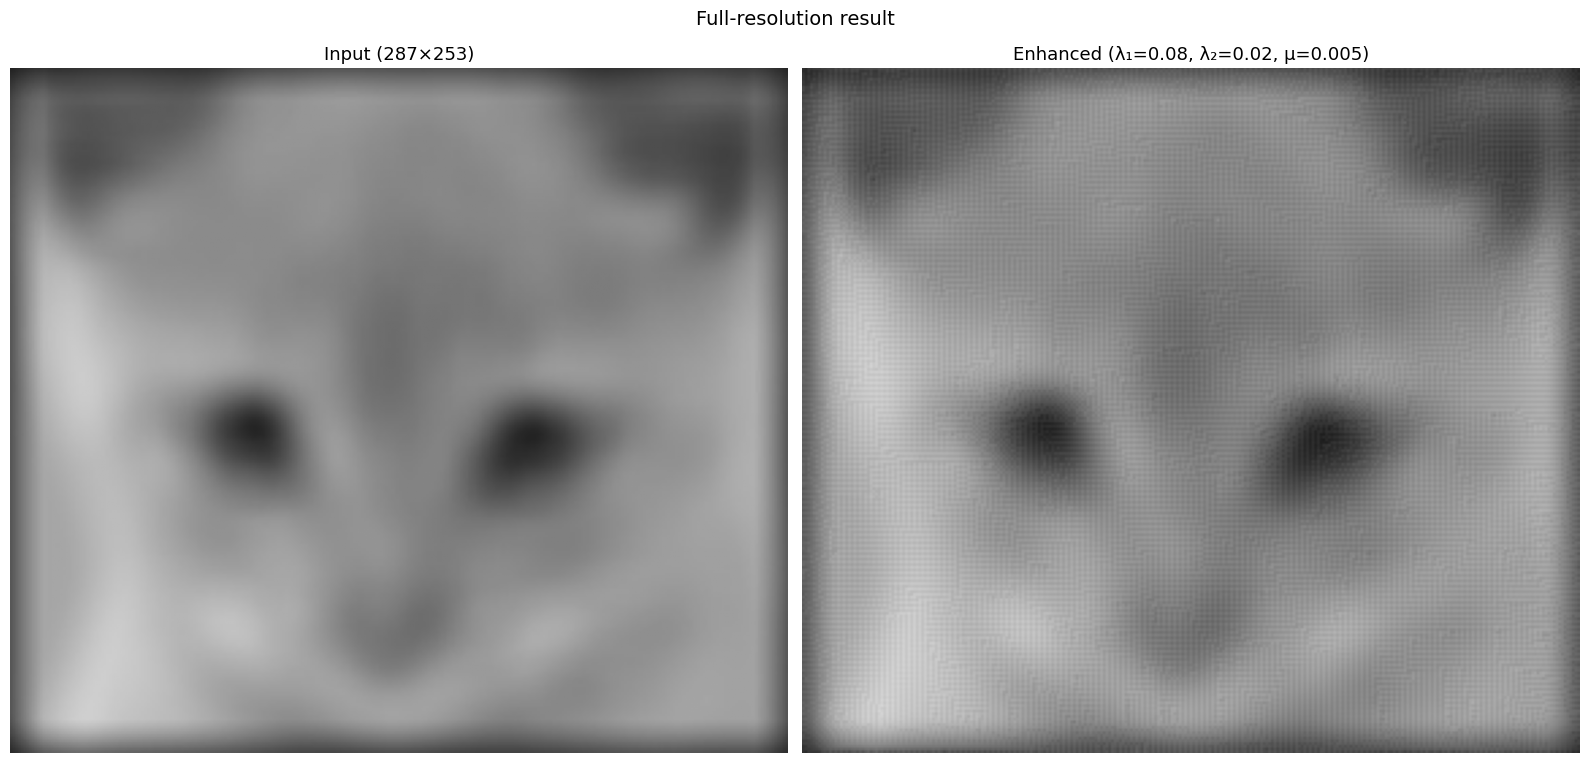

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(f_full, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Input ({W}×{H})', fontsize=13); axes[0].axis('off')
axes[1].imshow(u_out, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Enhanced (λ₁={LAMBDA1}, λ₂={LAMBDA2}, μ={MU})', fontsize=13)
axes[1].axis('off')
plt.suptitle('Full-resolution result', fontsize=14)
plt.tight_layout()
plt.savefig('fullres_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


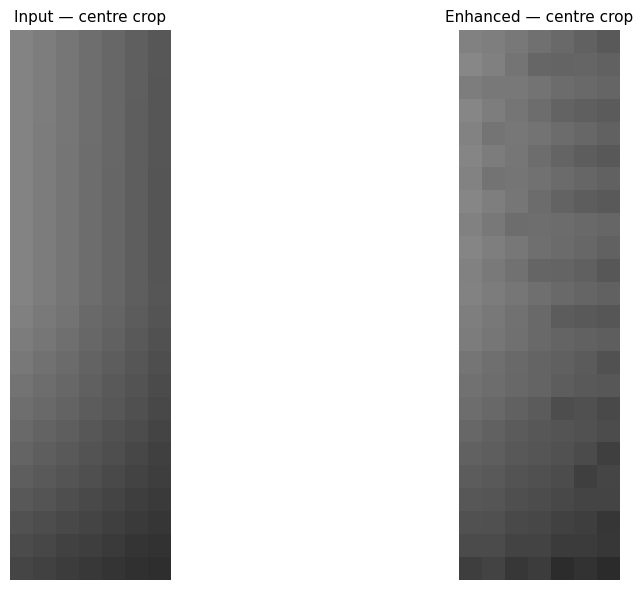

In [15]:
cy, cx = H//2, W//2; r = 150
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(f_full[cy-r:cy+r, cx-r:cx+r], cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[0].set_title('Input — centre crop', fontsize=11); axes[0].axis('off')
axes[1].imshow(np.clip(u_full[cy-r:cy+r, cx-r:cx+r], 0, 255), cmap='gray',
               vmin=0, vmax=255, interpolation='nearest')
axes[1].set_title('Enhanced — centre crop', fontsize=11); axes[1].axis('off')
plt.tight_layout()
plt.savefig('crop_fullres.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Tuning guide

| Effect you want | Change |
|---|---|
| Sharper edges | Raise `LAMBDA1` (e.g. 0.15) |
| Less noise | Raise `LAMBDA1` and `LAMBDA2` |
| Preserve fine texture | Lower `LAMBDA2` (e.g. 0.005) |
| Reduce cartoon / staircase artifact | Raise `LAMBDA2` |
| Compact estimated kernel | Raise `MU` (e.g. 0.01) |
| More iterations = better quality | Raise `FULLRES_ADMM` to 200 |
